# WHO Life Expectancy - Linear Regression Analysis
**Dataset:** WHO Life Expectancy Data  
**Target Variable:** Life Expectancy  
**Goal:** Predict life expectancy using socioeconomic and health indicators

## PART 1: Environment Setup

### Step 1: Importing Libraries

In [154]:
# Libraries to be used
import kaggle
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported successfully.')


Libraries imported successfully.


### Step 2: Download & Load Dataset

In [155]:
# Downloading the dataset from Kaggle
kaggle.api.dataset_download_files(
    'kumarajarshi/life-expectancy-who',
    path='.',
    unzip=True
)

print('Dataset downloaded successfully!')


Dataset URL: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
Dataset downloaded successfully!


In [156]:
# Loading the dataset into a DataFrame
data = pd.read_csv('./Life Expectancy Data.csv')

# Set to view all columns
pd.set_option('display.max_columns', None)

# Viewing the dataset (showing the first & last 5 rows)
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,27.1,42,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,26.7,41,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,26.3,40,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,25.9,39,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [157]:
# Displaying the shape of the dataset
print('Dataset has {} rows and {} columns.'.format(data.shape[0], data.shape[1]))

Dataset has 2938 rows and 22 columns.


## PART 2: Exploratory Data Analysis

### Step3: Data Overview and Missing Values

In [158]:
# Getting to Understand more the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [159]:
#Statistical summary of the dataset
data.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [160]:
# Checking for missing values in the dataset and their percentage per column
missing_df = pd.DataFrame({
    'Missing Count': data.isnull().sum(),
    'Missing Percentage(%)': (data.isnull().sum() / len(data) * 100).round(2)
})

# Show only columns that actually have missing values
# and Sort by percentage of missing values in descending order

print(missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Percentage(%)', ascending=False))


                                 Missing Count  Missing Percentage(%)
Population                                 652                  22.19
Hepatitis B                                553                  18.82
GDP                                        448                  15.25
Total expenditure                          226                   7.69
Alcohol                                    194                   6.60
Income composition of resources            167                   5.68
Schooling                                  163                   5.55
 thinness 5-9 years                         34                   1.16
 thinness  1-19 years                       34                   1.16
 BMI                                        34                   1.16
Polio                                       19                   0.65
Diphtheria                                  19                   0.65
Life expectancy                             10                   0.34
Adult Mortality     

### Step 4: Data Visualization and Interpretation

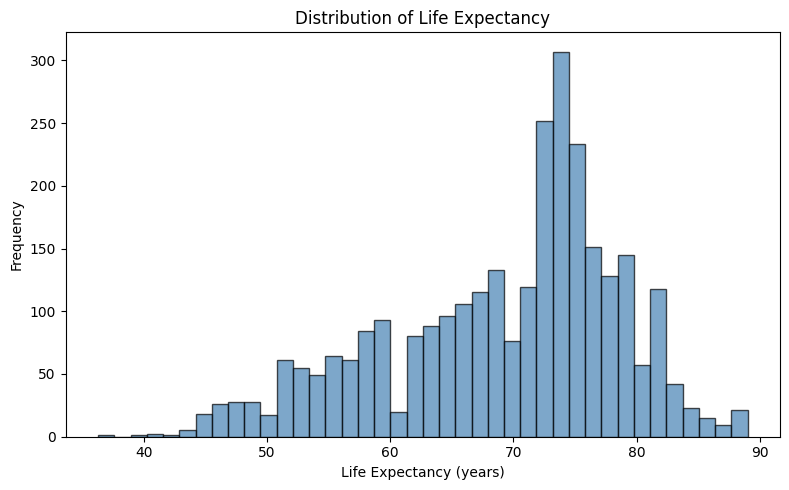

In [161]:
# Histogram of the 'Life expectancy' column which is the target variable

plt.figure(figsize=(8, 5))
plt.hist(data['Life expectancy '].dropna(), bins=40,
         color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

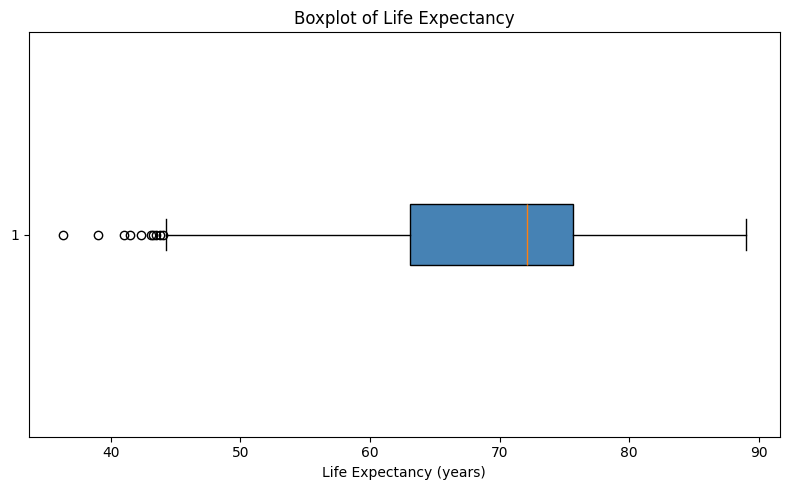

In [162]:
# Boxplot of Life Expectancy to detect outliers

plt.figure(figsize=(8, 5))
plt.boxplot(data['Life expectancy '].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Boxplot of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

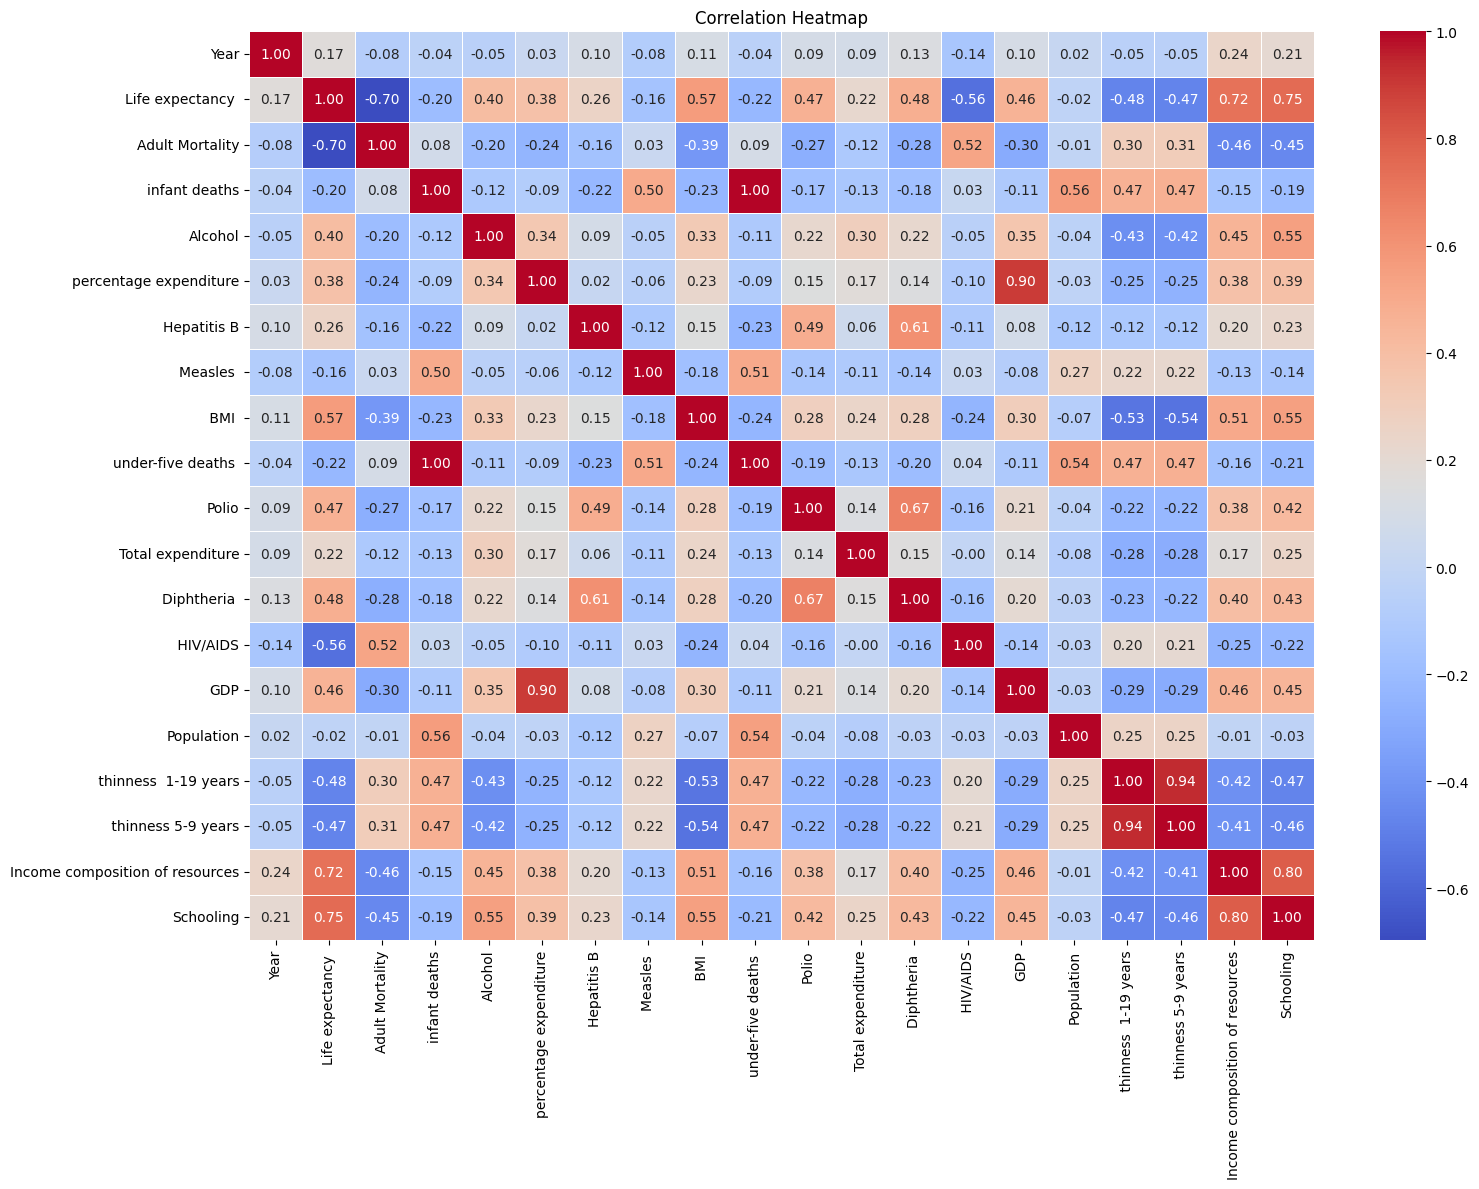

In [163]:
# Hitmap of the correlation on the dataset

# selecting numeric columns for correlation heatmap
data_numeric = data.select_dtypes(include=[np.number])
matrix = data_numeric.corr()

#plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## PART 3: Data Preprocessing

### Step 5: Data Cleaning & Columns renaming

In [164]:
# striping whitespace from column names
data.columns = data.columns.str.strip()

print('Column names after stripping whitespace:')
print(data.columns.tolist())

Column names after stripping whitespace:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [165]:
# Renaming columns for easier access & readability
data.rename(columns={
    'Life expectancy'                : 'Life_Expectancy',
    'infant deaths'                  : 'Infant_Deaths',
    'percentage expenditure'         : 'Pct_Expenditure',
    'Hepatitis B'                    : 'Hepatitis_B',
    'under-five deaths'              : 'Under5_Deaths',
    'Total expenditure'              : 'Total_Exp',
    'HIV/AIDS'                       : 'HIV_AIDS',
    'thinness  1-19 years'           : 'Thinness_1_19',
    'thinness 5-9 years'             : 'Thinness_5_9',
    'Income composition of resources': 'Income_Composition',
    'Adult Mortality'                : 'Adult_Mortality',
    'BMI'                            : 'BMI',
    'Diphtheria'                     : 'Diphtheria'
}, inplace=True)

print('Columns after rename')
print(list(data.columns))

Columns after rename
['Country', 'Year', 'Status', 'Life_Expectancy', 'Adult_Mortality', 'Infant_Deaths', 'Alcohol', 'Pct_Expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'Under5_Deaths', 'Polio', 'Total_Exp', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'Thinness_1_19', 'Thinness_5_9', 'Income_Composition', 'Schooling']


In [166]:
# Filling missing values in numeric columns with the mean of each column
# no column has more than 30% missing values. 
# no column to be removed because of that reason

numeric_columns = data.select_dtypes(include=[np.number]).columns.to_list()

for column in numeric_columns:
    column_mean = data[column].mean()
    missing_data = data[column].isnull().sum()
    data[column] = data[column].fillna(column_mean)
    if missing_data > 0:
        print(
            f'Filled {missing_data}     missing in  "{column}"  with mean:  {column_mean:.4f}')
print(f'\nRemaining missing values after filling: {data.isnull().sum().sum()}')

Filled 10     missing in  "Life_Expectancy"  with mean:  69.2249
Filled 10     missing in  "Adult_Mortality"  with mean:  164.7964
Filled 194     missing in  "Alcohol"  with mean:  4.6029
Filled 553     missing in  "Hepatitis_B"  with mean:  80.9405
Filled 34     missing in  "BMI"  with mean:  38.3212
Filled 19     missing in  "Polio"  with mean:  82.5502
Filled 226     missing in  "Total_Exp"  with mean:  5.9382
Filled 19     missing in  "Diphtheria"  with mean:  82.3241
Filled 448     missing in  "GDP"  with mean:  7483.1585
Filled 652     missing in  "Population"  with mean:  12753375.1201
Filled 34     missing in  "Thinness_1_19"  with mean:  4.8397
Filled 34     missing in  "Thinness_5_9"  with mean:  4.8703
Filled 167     missing in  "Income_Composition"  with mean:  0.6276
Filled 163     missing in  "Schooling"  with mean:  11.9928

Remaining missing values after filling: 0


### Step 6: Drop Irrelevant Columns

In [167]:
# Country: not a predictive feature, just an string identifier
# Year: just a time index identifier

data.drop(columns=['Country', 'Year'], inplace=True)

print('Dropped: Country & Year as irrelevant columns for prediction')
print(f'Remaining columns ({len(data.columns)}): {list(data.columns)}')

Dropped: Country & Year as irrelevant columns for prediction
Remaining columns (20): ['Status', 'Life_Expectancy', 'Adult_Mortality', 'Infant_Deaths', 'Alcohol', 'Pct_Expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'Under5_Deaths', 'Polio', 'Total_Exp', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'Thinness_1_19', 'Thinness_5_9', 'Income_Composition', 'Schooling']


### Step7 : Encode Categorical Variables

In [168]:
#Encoding the 'Status' column using one-hot encoding
#drop_first=True: keeps only Status_Developing (1=Developing, 0=Developed)

print('Status value counts before encoding:')
print(data['Status'].value_counts())

data = pd.get_dummies(data, columns=['Status'], drop_first=True, dtype=int)

status_cols = [c for c in data.columns if 'Status' in c]
print('\nEncoded columns:', status_cols)
print(f'\nFinal dataset shape: {data.shape}')
data.head(2)

Status value counts before encoding:
Status
Developing    2426
Developed      512
Name: count, dtype: int64

Encoded columns: ['Status_Developing']

Final dataset shape: (2938, 20)


,Life_Expectancy,Adult_Mortality,Infant_Deaths,Alcohol,Pct_Expenditure,Hepatitis_B,Measles,BMI,Under5_Deaths,Polio,Total_Exp,Diphtheria,HIV_AIDS,GDP,Population,Thinness_1_19,Thinness_5_9,Income_Composition,Schooling,Status_Developing
0,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,1
1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,1


## PART 4: Define Features & Scale Features

### Step 8: Define Features (X) &  Target (y)

In [169]:
# y is the target variable, X are the features matrix
# dropping Life_Expectancy from X , because it's the target variable
# Infant_Deaths is dropped because of its multicollinearity with Under5_Deaths (correlation of 0.95)

X = data.drop(columns=['Life_Expectancy', 'Infant_Deaths'])
y = data['Life_Expectancy']

print('Target variable (y): {}'.format(y.name))
print(f'Feature matrix  (X) shape: {X.shape}')
print(f'Target vector   (y) shape: {y.shape}')
print(f'\nFeatures ({X.shape[1]} in total):')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

Target variable (y): Life_Expectancy
Feature matrix  (X) shape: (2938, 18)
Target vector   (y) shape: (2938,)

Features (18 in total):
   1. Adult_Mortality
   2. Alcohol
   3. Pct_Expenditure
   4. Hepatitis_B
   5. Measles
   6. BMI
   7. Under5_Deaths
   8. Polio
   9. Total_Exp
  10. Diphtheria
  11. HIV_AIDS
  12. GDP
  13. Population
  14. Thinness_1_19
  15. Thinness_5_9
  16. Income_Composition
  17. Schooling
  18. Status_Developing


### Step 9: Train Test Split & Feature Scaling

In [170]:
# Split the data into 80% training and 20% testing sets
# random_state=42 ensures reproducibility of the split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Testing set   : {X_test.shape[0]} samples')


Training set  : 2350 samples
Testing set   : 588 samples


Standardizing the data

In [171]:

# Standardize the features using StandardScaler
# To prevent leakage, I fit scaler only on the training data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\nStandardScaler applied (fitted on training set only).')
print(f'  X_train_scaled shape: {X_train_scaled.shape}')
print(f'  X_test_scaled  shape: {X_test_scaled.shape}')



StandardScaler applied (fitted on training set only).
  X_train_scaled shape: (2350, 18)
  X_test_scaled  shape: (588, 18)


In [172]:
# display few rows of the scaled training features
scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print('First 5 rows of the scaled training features:')
display(scaled_df.head())

First 5 rows of the scaled training features:


,Adult_Mortality,Alcohol,Pct_Expenditure,Hepatitis_B,Measles,BMI,Under5_Deaths,Polio,Total_Exp,Diphtheria,HIV_AIDS,GDP,Population,Thinness_1_19,Thinness_5_9,Income_Composition,Schooling,Status_Developing
0,-0.318479,0.176102,-0.192120,0.665664,-0.200110,-0.654211,-0.262215,0.657270,-0.679478,0.658741,-0.225454,-0.327142,-0.240039,0.753741,0.709445,-0.143247,-0.038796,0.463109
1,-0.110535,-0.201213,-0.291864,-0.007317,-0.200110,-0.824603,-0.262215,0.356695,-0.309913,-3.093781,-0.187469,-0.467819,-0.240922,1.050729,1.001180,-0.341601,-0.315474,0.463109
2,-0.182516,1.497991,-0.369082,0.799728,-0.200110,0.297983,-0.262215,0.700210,0.682516,0.700904,-0.320418,0.006416,0.013396,-0.114379,-0.120876,0.506360,0.268623,0.463109
3,-1.222237,-0.848040,-0.064479,0.755040,-0.198729,1.039691,-0.242595,0.657270,0.549638,0.658741,-0.320418,-0.244175,-0.227062,0.365371,0.327946,0.441895,0.821978,0.463109
4,-0.566413,-1.145786,0.113299,0.799728,-0.200110,-0.528922,-0.262215,0.700210,-1.053196,0.490088,-0.320418,0.720946,0.013396,0.433907,0.283064,0.937778,0.391591,0.463109


In [173]:
# Displaying few rows of the scaled testing features
scaled_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print('First 5 rows of the scaled testing features:')
display(scaled_test_df.head())

First 5 rows of the scaled testing features:


,Adult_Mortality,Alcohol,Pct_Expenditure,Hepatitis_B,Measles,BMI,Under5_Deaths,Polio,Total_Exp,Diphtheria,HIV_AIDS,GDP,Population,Thinness_1_19,Thinness_5_9,Income_Composition,Schooling,Status_Developing
0,-0.342473,-0.930177,-0.306254,0.084720,-0.155491,0.498445,-0.196816,0.013180,-0.895404,-3.135945,-0.320418,-0.430169,0.140695,0.365371,0.327946,0.025353,-0.192506,0.463109
1,-0.422451,1.857339,0.427789,-0.007317,-0.200024,0.979553,-0.262215,0.571392,0.420913,0.574414,-0.320418,0.302533,-0.250080,-0.685511,-0.681904,0.754302,0.576042,-2.159317
2,-0.326477,0.099099,-0.021515,-3.222192,-0.200110,0.934449,-0.262215,0.399634,0.333712,0.405762,-0.320418,-0.110040,-0.237365,-0.616975,-0.592140,0.650166,0.483817,0.463109
3,-1.270224,-0.776171,-0.180958,0.755040,-0.196140,1.220107,-0.262215,0.657270,-0.397114,0.658741,-0.320418,1.341923,0.013396,0.296836,0.260623,0.937778,0.760494,0.463109
4,2.096873,-0.791571,-0.368732,-0.007317,1.612415,-1.210492,0.529116,-3.207274,-0.521686,-0.015870,3.098254,-0.561296,-0.185103,1.005039,0.956297,-0.906908,-1.114764,0.463109


## PART 5: Linear Regression Model

### Step 10: Initializing & Training The model 

In [174]:
#Initializing and training the Linear Regression model
model = LinearRegression()

# fit the model on the training data 
model.fit(X_train_scaled, y_train)

print('Model is created successfully!')

Model is created successfully!


### Step 11: Make Predictions & Comparison Table

In [175]:
#predict life expectancy on the testing set  
y_pred = model.predict(X_test_scaled)

# compare the predicted values with the actual values
comparison = pd.DataFrame({
    'Actual data': y_test.values.flatten(),
    'Predicted data': y_pred.flatten().round(2),
    'Difference': (y_test.values.flatten() - y_pred.flatten()).round(2)})

print('\nComparison of Actual vs Predicted Life Expectancy (first 15 rows):')
print(comparison.head(15).to_string(index=False))


Comparison of Actual vs Predicted Life Expectancy (first 15 rows):
 Actual data  Predicted data  Difference
        73.7           66.91        6.79
        75.9           77.37       -1.47
        74.2           75.81       -1.61
        76.8           78.34       -1.54
        51.9           47.40        4.50
        49.6           51.05       -1.45
        67.4           67.39        0.01
        73.9           70.73        3.17
        77.2           74.63        2.57
        55.0           54.34        0.66
        51.4           52.46       -1.06
        53.3           63.41      -10.11
        58.1           65.25       -7.15
        75.0           70.81        4.19
        69.1           70.63       -1.53


### Step 12: Inspect model coefficient

In [176]:
#baseline life expectancy when all scaled features = 0
print(f'Model Intercept: {float(model.intercept_):.4f}')

#Dataframe of the coefficients of the features
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print('\nFeature Coefficients (sorted by absolute value):')
print(coefficients_df.to_string(index=False))

Model Intercept: 69.2770

Feature Coefficients (sorted by absolute value):
           Feature  Coefficient
   Adult_Mortality    -2.639137
          HIV_AIDS    -2.474837
         Schooling     2.097952
Income_Composition     1.438567
        Diphtheria     1.097206
               BMI     0.833986
             Polio     0.711121
 Status_Developing    -0.621336
       Hepatitis_B    -0.445709
     Thinness_1_19    -0.386037
           Measles    -0.378532
               GDP     0.354761
     Under5_Deaths    -0.260413
   Pct_Expenditure     0.176958
        Population     0.167833
      Thinness_5_9     0.130424
         Total_Exp     0.102025
           Alcohol     0.100431


## PART 6: Model Evaluation

### Step 13: Regression Metrics

In [177]:
# Calculate Standard Regression Metrics using sklearn

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('\nModel Evaluation Metrics:')
print('-'*40)
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R-squared (R2): {r2:.4f}')


Model Evaluation Metrics:
----------------------------------------
Mean Absolute Error (MAE): 2.9536
Mean Squared Error (MSE): 16.2512
Root Mean Squared Error (RMSE): 4.0313
R-squared (R2): 0.8124


### Step 14: Visualizing Model Performance

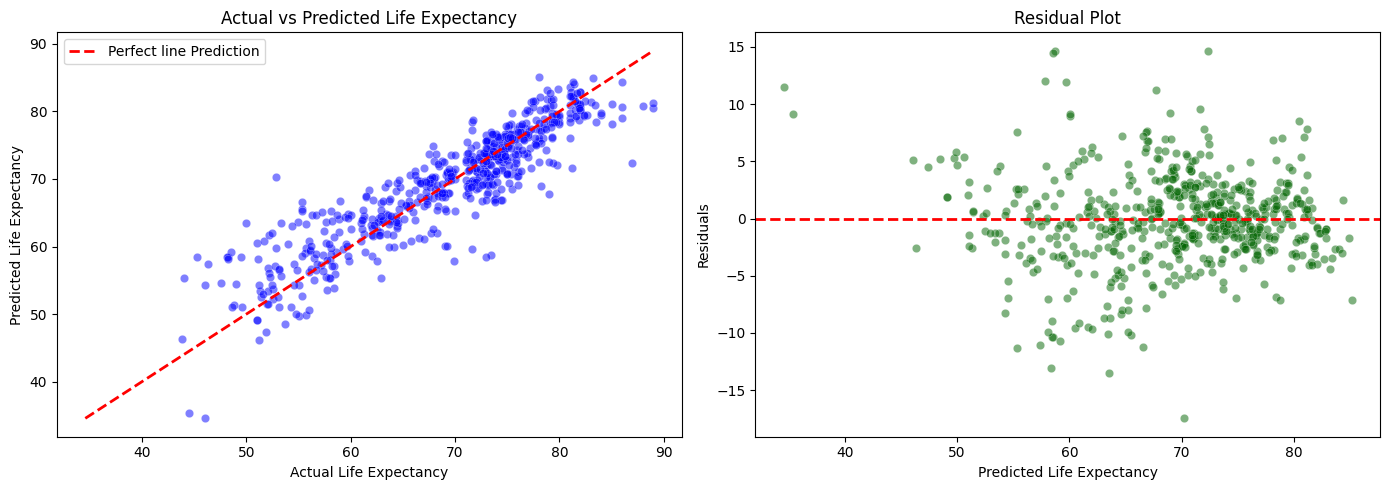

In [178]:
# Plot 1: Actual vs Predicted Data: perfect model 
# Plot 2: Residual plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='blue',
                edgecolors='white', linewidths=0.3)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--',
             linewidth=2, label='Perfect line Prediction')
axes[0].set_xlabel('Actual Life Expectancy')
axes[0].set_ylabel('Predicted Life Expectancy')
axes[0].set_title('Actual vs Predicted Life Expectancy')
axes[0].legend()

# Residual Plot
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='darkgreen',
                edgecolors='white', linewidths=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Life Expectancy')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

## PART 7: Multiple Models: Decision Tree & Random Forest

### Step 15: Importing Additional Libraries

In [179]:
# Import Decision Tree and Random Forest from sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

### Step 16: Regression by Decision Tree

In [180]:
# train a Decision Tree Regressor
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

# predicting
decision_tree_pred = decision_tree_model.predict(X_test_scaled)

# Evaluating the Decision Tree model
decision_tree_mae = mean_absolute_error(y_test, decision_tree_pred)
decision_tree_mse = mean_squared_error(y_test, decision_tree_pred)
decision_tree_rmse = np.sqrt(decision_tree_mse)
decision_tree_r2 = r2_score(y_test, decision_tree_pred)

print('\nDecision Tree Regressor Evaluation Metrics:')
print('-'*40)
print(f'Mean Absolute Error (MAE): {decision_tree_mae:.4f}')    
print(f'Mean Squared Error (MSE): {decision_tree_mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {decision_tree_rmse:.4f}')
print(f'R-squared (R2): {decision_tree_r2:.4f}')



Decision Tree Regressor Evaluation Metrics:
----------------------------------------
Mean Absolute Error (MAE): 1.5885
Mean Squared Error (MSE): 6.3600
Root Mean Squared Error (RMSE): 2.5219
R-squared (R2): 0.9266


### Step 17: Regression by Random Forest

In [181]:
# Train Random Forest Regressor: ensemble of decision trees
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_scaled, y_train)

# predicting
random_forest_pred = random_forest_model.predict(X_test_scaled)

# Evaluating the Random Forest model
random_forest_mae = mean_absolute_error(y_test, random_forest_pred)
random_forest_mse = mean_squared_error(y_test, random_forest_pred)
random_forest_rmse = np.sqrt(random_forest_mse)
random_forest_r2 = r2_score(y_test, random_forest_pred)

print('\nRandom Forest Regressor Evaluation Metrics:')
print('-'*40)
print(f'Mean Absolute Error (MAE): {random_forest_mae:.4f}')
print(f'Mean Squared Error (MSE): {random_forest_mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {random_forest_rmse:.4f}')
print(f'R-squared (R2): {random_forest_r2:.4f}')


Random Forest Regressor Evaluation Metrics:
----------------------------------------
Mean Absolute Error (MAE): 1.0740
Mean Squared Error (MSE): 2.7385
Root Mean Squared Error (RMSE): 1.6548
R-squared (R2): 0.9684


### Step 18: Comparing all Three Models

In [182]:
# side-by-side comparison of the three models: Linear Regression, Decision Tree, Random Forest
model_comparison= pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE':   [round(mae, 4),    round(decision_tree_mae, 4),  round(random_forest_mae, 4)],
    'MSE':   [round(mse, 4),    round(decision_tree_mse, 4),  round(random_forest_mse, 4)],
    'RMSE':  [round(rmse, 4),   round(decision_tree_rmse, 4), round(random_forest_rmse, 4)],
    'R2':    [round(r2, 4),     round(decision_tree_r2, 4),   round(random_forest_r2, 4)]
})

print('Comparison of Linear Regression, Decision Tree, and Random Forest models:\n')
print(model_comparison.to_string(index=False))

# Identifying the best performing model based on R2 score
best_index = model_comparison['R2'].idxmax()
best_model = model_comparison.loc[best_index, 'Model']

print(f'\nBest performing model based on R2 score: {best_model} (R2 = {model_comparison.loc[best_index, "R2"]:.4f})')

Comparison of Linear Regression, Decision Tree, and Random Forest models:

            Model    MAE     MSE   RMSE     R2
Linear Regression 2.9536 16.2512 4.0313 0.8124
    Decision Tree 1.5885  6.3600 2.5219 0.9266
    Random Forest 1.0740  2.7385 1.6548 0.9684

Best performing model based on R2 score: Random Forest (R2 = 0.9684)


## PART 9: Linear Regression with Gradient Descent 

### Step 19: Train with SDGRegressor & Loss curve Plotting

In [183]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import SGDRegressor

# undisplay convergence warnings that was expected since max_iter=1 is intentional
warnings.filterwarnings('ignore', category=ConvergenceWarning)

train_losses = []
test_losses  = []

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                          learning_rate='constant', eta0=0.01)

n_epochs = 100

for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train)
    
    train_pred_epoch = sgd_model.predict(X_train_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred_epoch))
    
    test_pred_epoch = sgd_model.predict(X_test_scaled)
    test_losses.append(mean_squared_error(y_test, test_pred_epoch))

print(f'SGD Training complete over {n_epochs} epochs.')
print('-'*36)
print(f'Final Train MSE : {train_losses[-1]:.4f}')
print(f'Final Test  MSE : {test_losses[-1]:.4f}')
print(f'Final Test  R²  : {r2_score(y_test, sgd_model.predict(X_test_scaled)):.4f}')

SGD Training complete over 100 epochs.
------------------------------------
Final Train MSE : 21.4413
Final Test  MSE : 21.6469
Final Test  R²  : 0.7501


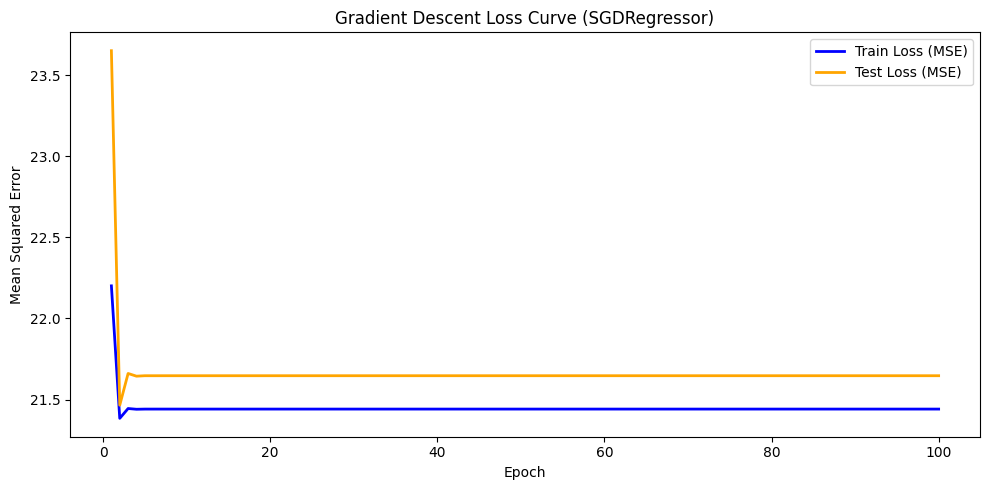

In [184]:
# Plot loss curve for train and test data across epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss (MSE)', color='blue', linewidth=2)
plt.plot(range(1, len(test_losses) + 1),  test_losses,  label='Test Loss (MSE)',  color='orange', linewidth=2)
plt.title('Gradient Descent Loss Curve (SGDRegressor)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.show()


## PART 10: Scatter Plot

### Step 20: Scatter Plot before & After with Regression Line

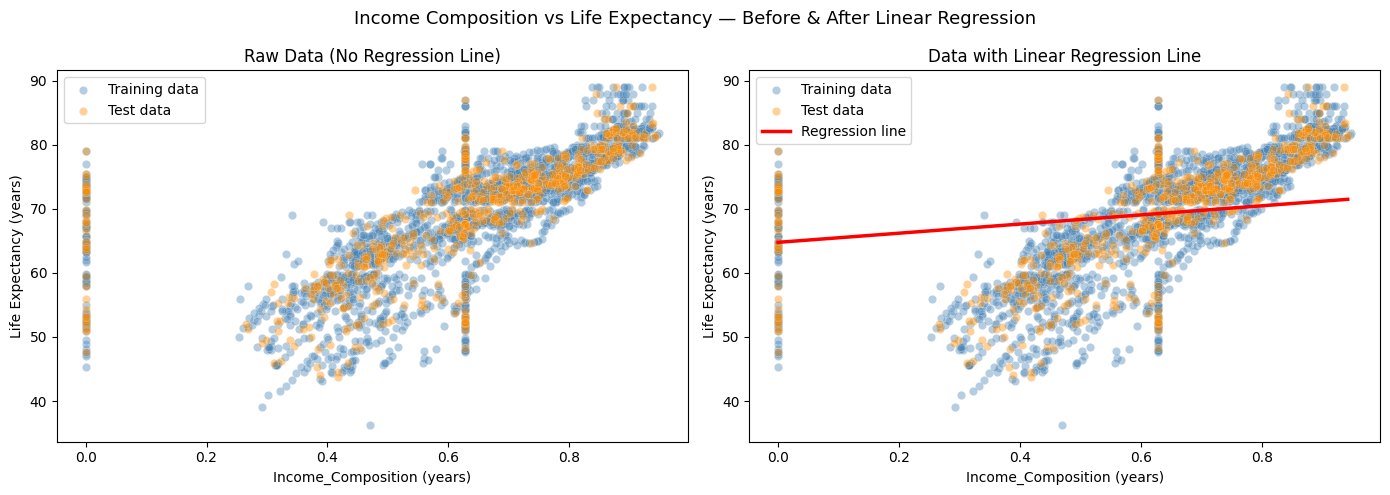

In [185]:
# Used Income_Composition vs Life_Expectancy 
# It is represented as the strongest interpretable relationship

feature = 'Income_Composition'
feature_index  = list(X.columns).index(feature)

# Extract original feature values
X_feature_train = X_train[feature].values
X_feature_test  = X_test[feature].values

# plotting two graphs as subplots: 
# one before adding regression line, another after adding regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#scatter with no regression line (considered as before adding regression line)

axes[0].scatter(X_feature_train, y_train, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, label='Training data')
axes[0].scatter(X_feature_test,  y_test,  alpha=0.4, color='darkorange',
                edgecolors='white', linewidths=0.3, label='Test data')
axes[0].set_title('Raw Data (No Regression Line)')
axes[0].set_xlabel(f'{feature} (years)')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].legend()

#Scatter with regression line (considered as after adding regression line)
# Generating regression line using the scaled feature column

X_line = np.linspace(X_feature_test.min(), X_feature_test.max(), 300).reshape(-1, 1)

#full scaled feature array using mean values for all other features

X_line_full = np.tile(X_train_scaled.mean(axis=0), (300, 1))
X_line_full[:, feature_index] = (X_line.flatten() - X_train[feature].mean()) / X_train[feature].std()

y_line = model.predict(X_line_full)

axes[1].scatter(X_feature_train, y_train, alpha=0.4, color='steelblue',
                edgecolors='white', linewidths=0.3, label='Training data')
axes[1].scatter(X_feature_test,  y_test,  alpha=0.4, color='darkorange',
                edgecolors='white', linewidths=0.3, label='Test data')
axes[1].plot(X_line, y_line, color='red', linewidth=2.5, label='Regression line')
axes[1].set_title('Data with Linear Regression Line')
axes[1].set_xlabel(f'{feature} (years)')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].legend()

plt.suptitle('Income Composition vs Life Expectancy — Before & After Linear Regression', fontsize=13)
plt.tight_layout()
plt.show()

## PART 11: Saving The Best Performing Model

### Step 21: Saving using pickle

In [186]:
import pickle

# determining the best model based on R2 score among the three models: 
# Linear Regression, Decision Tree, Random Forest

models = {
    'Linear Regression': (model,    r2),
    'Decision Tree':     (decision_tree_model, decision_tree_r2),
    'Random Forest':     (random_forest_model, random_forest_r2)
}

best_name  = max(models, key=lambda k: models[k][1])
best_model = models[best_name][0]
best_r2    = models[best_name][1]

# Save best model and its scaler in saved_models directory
os.makedirs('saved_models', exist_ok=True)
model_path = './saved_models/best_model.pkl'
scaler_path = './saved_models/scaler.pkl'

with open(model_path, 'wb') as file1:
    pickle.dump(best_model, file1)

with open(scaler_path, 'wb') as file2:
    pickle.dump(scaler, file2)

print(f'Best model      : {best_name}')
print(f'Best R2 score   : {best_r2:.4f}')
print(f'Model saved to  : {model_path}')
print(f'Scaler saved to : {scaler_path}')

Best model      : Random Forest
Best R2 score   : 0.9684
Model saved to  : ./saved_models/best_model.pkl
Scaler saved to : ./saved_models/scaler.pkl


### Step 22: Verifying the saved model

In [187]:
# Loading the saved best performing model and its scaler 
with open('./saved_models/best_model.pkl', 'rb') as file1:
    prediction_model = pickle.load(file1)

with open('./saved_models/scaler.pkl', 'rb') as file2:
    prediction_scaler = pickle.load(file2)

# input data point from the test set 
input = X_test.iloc[[0]]  
actual_value = y_test.values[0]

# Scale the input using the saved scaler 
value_scaled = prediction_scaler.transform(input)

# predicting
predicted_value = prediction_model.predict(value_scaled)[0]

# result
print('Prediction Script: ')
print(f'Model used       : {best_name}')
print(f'Input features   : {input.shape[1]} features')
print('-' * 40)
print(f'Predicted Life Expectancy : {predicted_value:.2f} years')
print(f'Actual Life Expectancy    : {actual_value:.2f} years')
print(f'Difference                : {actual_value - predicted_value:.2f} years')
print('-' * 40)

Prediction Script: 
Model used       : Random Forest
Input features   : 18 features
----------------------------------------
Predicted Life Expectancy : 73.11 years
Actual Life Expectancy    : 73.70 years
Difference                : 0.59 years
----------------------------------------
